# PyTorch Basics: Tensors & Gradients

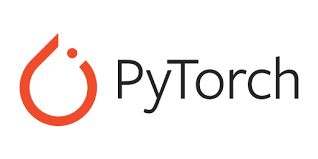



  PyTorch is an open-source machine learning framework that is primarily used for developing and training deep learning models. It was developed by Facebook's AI Research Lab and released in 2016. PyTorch provides a flexible and dynamic approach to building neural networks, making it a popular choice among researchers and developers.

The framework is built on a dynamic computational graph concept, which means that the graph is built and modified on-the-fly as the program runs. This allows for more intuitive and flexible model development, as you can use standard Python control flow statements and debug the model easily.

PyTorch supports automatic differentiation, which enables efficient computation of gradients for training neural networks using backpropagation. It provides a rich set of tools and libraries for tasks such as data loading, model building, optimization, and evaluation.

One of the key advantages of PyTorch is its support for GPU acceleration, allowing you to train models on GPUs to significantly speed up computations. It also has a large and active community, which means there are plenty of resources, tutorials, and pre-trained models available.

PyTorch is often compared to TensorFlow, another popular deep learning framework. While TensorFlow focuses more on static computation graphs, PyTorch emphasizes dynamic computation graphs. This fundamental difference in design philosophy gives PyTorch an edge when it comes to flexibility and ease of use.

Overall, PyTorch is widely used in the research community and is gaining popularity in industry applications as well. It provides a powerful and user-friendly platform for building and training deep learning models.

In [1]:
import torch as t

In [2]:
t.__version__

'2.11.0+cu128'

# Tensors

In [3]:
# Number/Scalar
t1 = t.tensor(4.)
t1
# 4. is a shorthand notation for 4.0

tensor(4.)

In [4]:
t1.dtype

torch.float32

In [5]:
#Vector
t2 = t.tensor([1.,2.,3.,4.])
t2

tensor([1., 2., 3., 4.])

In [6]:
# matrix
t3 = t.tensor([
    [5.,6.],
    [7,8],
    [9,10]
])
t3

tensor([[ 5.,  6.],
        [ 7.,  8.],
        [ 9., 10.]])

In [7]:
# 3 dimensional array
t4 = t.tensor([
    [
        [11,12,13],
        [14,15,16],
    ],
    [
        [17,18,19],
        [20,21,22]
    ]
])
t4

tensor([[[11, 12, 13],
         [14, 15, 16]],

        [[17, 18, 19],
         [20, 21, 22]]])

In [8]:
print(t1)
t1.shape

tensor(4.)


torch.Size([])

In [9]:
print(t2)
t2.shape

tensor([1., 2., 3., 4.])


torch.Size([4])

In [10]:
print(t3)
t3.shape

tensor([[ 5.,  6.],
        [ 7.,  8.],
        [ 9., 10.]])


torch.Size([3, 2])

In [11]:
print(t4)
t4.shape

tensor([[[11, 12, 13],
         [14, 15, 16]],

        [[17, 18, 19],
         [20, 21, 22]]])


torch.Size([2, 2, 3])

#Tensor operation and gradients

In [12]:
# Create tensors
x = t.tensor(3.)
w = t.tensor(4. , requires_grad=True)
b = t.tensor(5. , requires_grad=True)

In [13]:
x,w,b

(tensor(3.), tensor(4., requires_grad=True), tensor(5., requires_grad=True))

In [14]:
# Arithemitc operations
y = x*w+b
y

tensor(17., grad_fn=<AddBackward0>)

In [15]:
# Compute derivates
y.backward()

In [16]:
# Display gradients
print(f"dy/dx: {x.grad}")
print(f"dw/dx: {w.grad}")
print(f"db/dx: {b.grad}")

dy/dx: None
dw/dx: 3.0
db/dx: 1.0


#Tensor functions

In [17]:
# Create a tensor with a fixed value for every elemnt
t5 = t.full((3,2),42)

In [18]:
t5

tensor([[42, 42],
        [42, 42],
        [42, 42]])

In [19]:
# Concatinate two tensors with compatible shapes
t6 = t.cat((t5,t3))
t6

tensor([[42., 42.],
        [42., 42.],
        [42., 42.],
        [ 5.,  6.],
        [ 7.,  8.],
        [ 9., 10.]])

In [20]:
# the sin value of each element
t7=t.sin(t6)
t7

tensor([[-0.9165, -0.9165],
        [-0.9165, -0.9165],
        [-0.9165, -0.9165],
        [-0.9589, -0.2794],
        [ 0.6570,  0.9894],
        [ 0.4121, -0.5440]])

In [21]:
# change the shape of a tensor
t8 = t6.reshape(3,2,2)

In [22]:
t8

tensor([[[42., 42.],
         [42., 42.]],

        [[42., 42.],
         [ 5.,  6.]],

        [[ 7.,  8.],
         [ 9., 10.]]])

# Interoperability with Numpy

In [23]:
import numpy as np

x = np.array([[1,2],[3,4.]])
x

array([[1., 2.],
       [3., 4.]])

In [24]:
y = t.from_numpy(x)
y

tensor([[1., 2.],
        [3., 4.]], dtype=torch.float64)

In [25]:
z = y.numpy()
z

array([[1., 2.],
       [3., 4.]])

# Linear Regression from Scratch using pytorch

In [26]:
# Making training data
# Input ---> (temp, rainfall, humidity) ---> yield of apple and oranges crops

input = np.array([
    [73, 67,43],
    [91, 88, 64],
    [87, 134, 58],
    [102, 43, 37],
    [69, 96, 70]
],dtype='float32')

In [27]:
# Target (apples, oranges)
target = np.array([
    [56, 70],
    [81, 101],
    [119, 113],
    [22, 37],
    [103, 119]
], dtype = 'float32')

In [28]:
# Convert inputs and target to tensors
inputs = t.from_numpy(input)
target = t.from_numpy(target)

print(inputs)
print(target)

tensor([[ 73.,  67.,  43.],
        [ 91.,  88.,  64.],
        [ 87., 134.,  58.],
        [102.,  43.,  37.],
        [ 69.,  96.,  70.]])
tensor([[ 56.,  70.],
        [ 81., 101.],
        [119., 113.],
        [ 22.,  37.],
        [103., 119.]])


In [29]:
# Weights and biases
w = t.randn(2,3,requires_grad=True)
b = t.randn(2,requires_grad=True)
print(w)
print(b)

tensor([[-0.6719, -0.0448, -1.8602],
        [-2.0799, -0.4766, -0.1924]], requires_grad=True)
tensor([-1.2083,  0.9633], requires_grad=True)


In [30]:
#define model
def model(x):
  return x @ w.t() + b

In [31]:
# prediction
preds = model(inputs)
preds

tensor([[-133.2440, -191.0741],
        [-185.3420, -242.5606],
        [-173.5540, -255.0097],
        [-140.4926, -238.7999],
        [-182.0798, -201.7690]], grad_fn=<AddBackward0>)

In [32]:
# loss funtion we will use is MSE -> Mean squared error
def loss(y,y_hat):
  diff = y-y_hat
  return t.sum(diff*diff)/diff.numel()

In [33]:
 # error
current_loss = loss(target,preds)
current_loss

tensor(80059.6562, grad_fn=<DivBackward0>)

In [34]:
#Compute gradients
current_loss.backward()

In [35]:
print(w)
print(w.grad)

tensor([[-0.6719, -0.0448, -1.8602],
        [-2.0799, -0.4766, -0.1924]], requires_grad=True)
tensor([[-19949.7773, -21934.9062, -13623.8652],
        [-26520.7832, -27938.3652, -17443.4121]])


In [36]:
print(b)
print(b.grad)

tensor([-1.2083,  0.9633], requires_grad=True)
tensor([-239.1425, -313.8427])


In [37]:
#reset grad
w.grad.zero_()
b.grad.zero_()

print(w.grad)
print(b.grad)

tensor([[0., 0., 0.],
        [0., 0., 0.]])
tensor([0., 0.])


In [38]:
# Adjust params
preds = model(inputs)
print(preds)
print(target)

current_loss = loss(target,preds)
current_loss

tensor([[-133.2440, -191.0741],
        [-185.3420, -242.5606],
        [-173.5540, -255.0097],
        [-140.4926, -238.7999],
        [-182.0798, -201.7690]], grad_fn=<AddBackward0>)
tensor([[ 56.,  70.],
        [ 81., 101.],
        [119., 113.],
        [ 22.,  37.],
        [103., 119.]])


tensor(80059.6562, grad_fn=<DivBackward0>)

In [39]:
current_loss.backward()
print(w.grad)
print(b.grad)

tensor([[-19949.7773, -21934.9062, -13623.8652],
        [-26520.7832, -27938.3652, -17443.4121]])
tensor([-239.1425, -313.8427])


*is a PyTorch context manager that temporarily disables gradient tracking.

`Simple definition
t.no_grad() tells PyTorch not to calculate or store gradients for the operations inside the block.`

In [40]:
# adjust weight & reset grad
learning_rate = 1e-5

with t.no_grad():
  w -= w.grad * 1e-5
  b -= b.grad * 1e-5

  w.grad.zero_()
  b.grad.zero_()

In [41]:
print(w)
print(b)

tensor([[-0.4724,  0.1746, -1.7239],
        [-1.8147, -0.1972, -0.0179]], requires_grad=True)
tensor([-1.2059,  0.9665], requires_grad=True)


In [42]:
# Calculate again
preds = model(inputs)
current_loss = loss(target,preds)
current_loss

tensor(54083.4883, grad_fn=<DivBackward0>)

In [43]:
# Training for muliple epochs
for i in range(4000):
  preds = model(inputs)
  current_loss = loss(target,preds)
  current_loss.backward()
  with t.no_grad():
    w -= w*1e-5
    b -= b*1e-5

    w.grad.zero_()
    b.grad.zero_()

  print(f"Epochs({i}/{100}) & Loss {current_loss}")

Epochs(0/100) & Loss 54083.48828125
Epochs(1/100) & Loss 54082.8046875
Epochs(2/100) & Loss 54082.1328125
Epochs(3/100) & Loss 54081.44921875
Epochs(4/100) & Loss 54080.76171875
Epochs(5/100) & Loss 54080.07421875
Epochs(6/100) & Loss 54079.3984375
Epochs(7/100) & Loss 54078.7109375
Epochs(8/100) & Loss 54078.0390625
Epochs(9/100) & Loss 54077.3515625
Epochs(10/100) & Loss 54076.66796875
Epochs(11/100) & Loss 54075.98828125
Epochs(12/100) & Loss 54075.3046875
Epochs(13/100) & Loss 54074.625
Epochs(14/100) & Loss 54073.9453125
Epochs(15/100) & Loss 54073.26171875
Epochs(16/100) & Loss 54072.57421875
Epochs(17/100) & Loss 54071.89453125
Epochs(18/100) & Loss 54071.21875
Epochs(19/100) & Loss 54070.53125
Epochs(20/100) & Loss 54069.84375
Epochs(21/100) & Loss 54069.1640625
Epochs(22/100) & Loss 54068.48828125
Epochs(23/100) & Loss 54067.80078125
Epochs(24/100) & Loss 54067.1171875
Epochs(25/100) & Loss 54066.4375
Epochs(26/100) & Loss 54065.76171875
Epochs(27/100) & Loss 54065.07421875
Ep

In [44]:
preds = model(inputs)
cur_loss = loss(target, preds)
print(cur_loss)

tensor(51441.3047, grad_fn=<DivBackward0>)


In [45]:
from math import sqrt
sqrt(cur_loss)

/tmp/ipykernel_12536/2601574392.py:2: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  sqrt(cur_loss)


226.80675626510777

In [46]:
preds

tensor([[ -94.2766, -139.7866],
        [-133.7072, -175.5113],
        [-114.2392, -177.1493],
        [-101.5257, -185.6994],
        [-132.3185, -138.7719]], grad_fn=<AddBackward0>)

In [47]:
target

tensor([[ 56.,  70.],
        [ 81., 101.],
        [119., 113.],
        [ 22.,  37.],
        [103., 119.]])

#Fashion MNIST Neural Net example using Pytorch

In [48]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor,Lambda,Compose
import matplotlib.pyplot as plt


In [49]:
# Download training data from open datasets
training_data = datasets.FashionMNIST(
    root = 'data',
    train=True,
    download=True,
    transform=ToTensor(),
)

# Download test data from open datasets
test_data = datasets.FashionMNIST(
    root = 'data',
    train=False,
    download=True,
    transform=ToTensor(),
)

In [50]:
type(training_data)

torchvision.datasets.mnist.FashionMNIST

In [51]:
# Get cpu or gpu device for training
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


*A DataLoader is used to load and organize training data in batches so that a neural network can process it efficiently.

`Simple definition
DataLoader takes a Dataset and provides the data to the model batch-by-batch, optionally shuffling it and loading it efficiently.`

In [52]:
batch_size=64

# create dataloaders
train_dataloader = DataLoader(training_data,batch_size=batch_size)
test_dataloader = DataLoader(test_data,batch_size=batch_size)

for x,y in test_dataloader:
  print("Shape of X [N,C,H,W]: ",x.shape)
  print("Shape of y:",y.shape,y.dtype)
  break

Shape of X [N,C,H,W]:  torch.Size([64, 1, 28, 28])
Shape of y: torch.Size([64]) torch.int64


* Logits are the raw output scores produced by the final layer of the neural network, before applying Softmax.
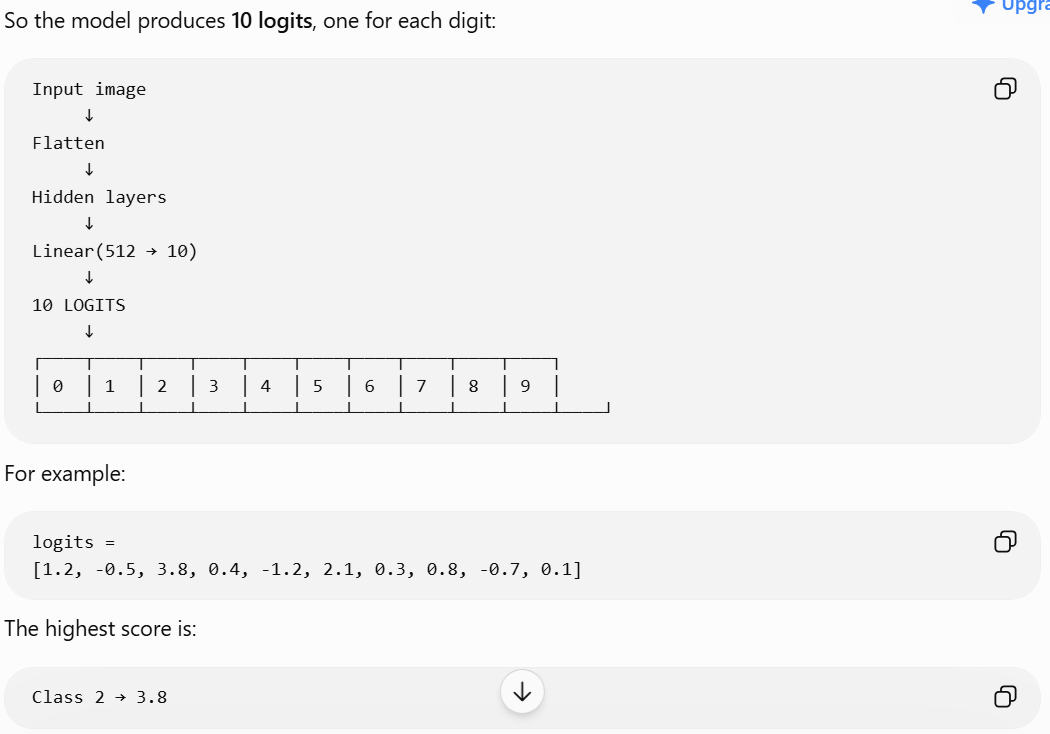

In [53]:
# define the NN Model
class NeuralNetwork(nn.Module):
  def __init__(self):
    super(NeuralNetwork,self).__init__()

    self.flatten = nn.Flatten()

    self.linear_relu_stack = nn.Sequential(
        nn.Linear(28*28,512),
        nn.ReLU(),
        nn.Linear(512,512),
        nn.ReLU(),
        nn.Linear(512,10)
        )

  def forward(self,x):
    x = self.flatten(x)
    logits = self.linear_relu_stack(x)
    return logits


model = NeuralNetwork().to(device)
print(model)

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)


In [54]:
# Cross Entropy Loss ----> Because it is a multiclass classification problem
loss_fn = nn.CrossEntropyLoss()

# Optimizer ---> SGD ---> Stochastic Gradient Descent
# lr = Learning Rate
Optimizer = torch.optim.SGD(model.parameters(),lr=1e-3)

* optimizer.step() updates the model's weights and biases using the gradients calculated by loss.backward().


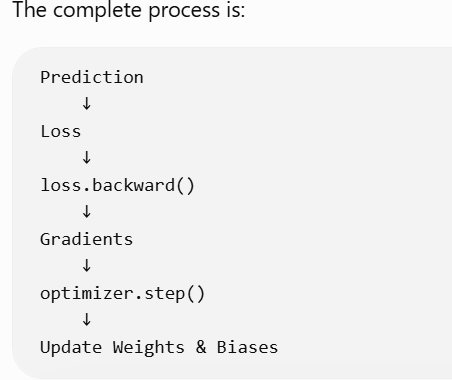

In [55]:
# Model Training
def train(dataloader,model,loss_fn,optimizer):
  size=len(dataloader.dataset)
  model.train()

  for batch,(x,y) in enumerate(dataloader):
    x,y = x.to(device),y.to(device) # related to gpu computation

    # compute prediction error
    pred = model(x)
    cur_loss = loss_fn(pred,y)

    # back propogation
    optimizer.zero_grad()
    cur_loss.backward()
    optimizer.step()

    if batch % 100 == 0:
      cur_loss,current = cur_loss.item(),batch*len(x)
      print(f"Loss: {cur_loss} [{current}/{size}]")

In [56]:
def test(dataloader,model,loss_fn):
  size = len(dataloader.dataset)
  num_batches = len(dataloader)
  model.eval()

  test_loss, correct = 0, 0 # Initialize test_loss and correct

  with torch.no_grad():
    for x,y in dataloader:
      x,y = x.to(device),y.to(device)
      pred = model(x)

      test_loss += loss_fn(pred,y).item()
      correct += (pred.argmax(1)==y).type(torch.float).sum().item()

  test_loss /= num_batches # average loss per batch
  correct /= size # %age of correct predictions or accuracy

  print(f"Test Error: \n Accuracy: {100*correct}%,Avg loss {test_loss}")

In [57]:
epochs = 1
for t in range(epochs):
  print(f"{t+1} \n ---------------------")
  train(train_dataloader,model,loss_fn,Optimizer)
  test(test_dataloader,model,loss_fn)

print("DONE\n")

1 
 ---------------------
Loss: 2.292933464050293 [0/60000]
Loss: 2.2922751903533936 [6400/60000]
Loss: 2.2686855792999268 [12800/60000]
Loss: 2.2595317363739014 [19200/60000]
Loss: 2.2486562728881836 [25600/60000]
Loss: 2.218095302581787 [32000/60000]
Loss: 2.221785545349121 [38400/60000]
Loss: 2.192427635192871 [44800/60000]
Loss: 2.1852965354919434 [51200/60000]
Loss: 2.147094249725342 [57600/60000]
Test Error: 
 Accuracy: 43.230000000000004%,Avg loss 2.1508218376499832
DONE



In [58]:
#save model
torch.save(model.state_dict(),'model.pth')
print("Saved model state to model.pth")

Saved model state to model.pth


In [60]:
# Prediction

classes = [
    "T-shirt/top",

"Trouser",

"Pullover",

"Dress",

"Coat",

"Sandal",

"Shirt",

"Sneaker",

"Bag",

"Ankle boot"

]

model.eval()

x,y = test_data[10][0],test_data[10][1]
x = x.to(device)
# y = y.to(device)
with torch.no_grad():
  pred = model(x)
  predicted, actual = classes[pred[0].argmax(0)],classes[y]

  print(f"Predicted: {predicted} Actual: {actual}")

Predicted: Pullover Actual: Coat


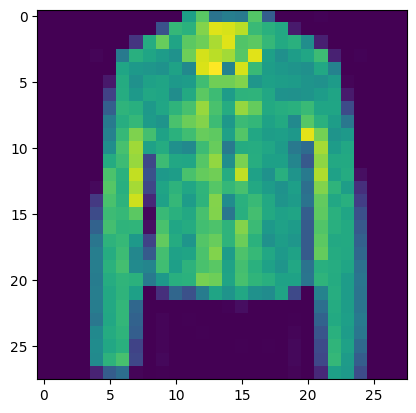

In [61]:
import matplotlib.pyplot as plt

# Assuming 'x' contains the image data
plt.imshow(x.cpu().squeeze())  # Move tensor to CPU if using GPU
plt.show()